In [ ]:
# =============================================================================
# COLAB NOTEBOOK: EDUCATION FEE BURDEN IN INDIAN HOUSEHOLDS (NSS 75 + CMS 2025)
# =============================================================================
# This notebook builds a full pipeline:
# 1. Load NSS 75th Round and CMS 2025 education microdata
# 2. Construct household-level education expenditure and fee-burden metrics
# 3. Perform exploratory data analysis (EDA)
# 4. Train and evaluate classification models to predict high fee burden
# 5. Generate SHAP-based explainability plots for Random Forest models
# 6. Plot national education expenditure trends using the Dataful file
# =============================================================================

In [ ]:
# =============================================================================
# 0. ENVIRONMENT SETUP
# =============================================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q pandas numpy scikit-learn matplotlib seaborn xgboost shap scipy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =============================================================================
# 1. IMPORT LIBRARIES
# =============================================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

import shap
import scipy.sparse as sp

shap.initjs()

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [ ]:
# =============================================================================
# 2. CONFIGURATION: FILE PATHS (EDIT BASE_PATH AS NEEDED)
# =============================================================================
# Put all CSVs under this folder in your Google Drive:
# Example: /content/drive/MyDrive/capstone_data

BASE_PATH = "/content/drive/MyDrive/capstone_data"  # <-- EDIT THIS IF REQUIRED

# NSS 75th Round – Block 3, 5, 6
NSS_B3_PATH = f"{BASE_PATH}/R75252L02-Block-3-household-characteristics.csv"
NSS_B5_PATH = f"{BASE_PATH}/R75252L05-Block-5-Dducation-particulars-on-basic-course-of-the-persons-of-age-3-to-35-years-who-are-currently-attending-education.csv"
NSS_B6_PATH = f"{BASE_PATH}/R75252L06-Block-6-Particulars-of-expenditure-Rs.-for-persons-of-age-3-to-35-years-who-are-currently-attending-at-pre-primary-and-above-level.csv"

# CMS Education 2025 – household, person, and status files
CMS_HH_PATH = f"{BASE_PATH}/CMSE80HH25.csv"
CMS_PER_PATH = f"{BASE_PATH}/CMSE80PER25.csv"
CMS_ST_PATH = f"{BASE_PATH}/CMSE80PERST25.csv"

# Dataful national education expenditure file
EDU_EXP_PATH = f"{BASE_PATH}/all-india-and-year-wise-expenditure-on-education.csv"
EDU_META_PATH = f"{BASE_PATH}/metadata.csv"

In [ ]:
# =============================================================================
# 2. CONFIGURATION: FILE PATHS
# =============================================================================
# Putting all CSVs in a folder on Google Drive:

BASE_PATH = "/content/drive/My Drive/MS Drive/Masters Term 3/capstone_data"

# NSS 75th Round – Block 3, 5, 6 (use your exact filenames)
NSS_B3_PATH = f"{BASE_PATH}/R75252L02-Block-3-household-characteristics.csv"
NSS_B5_PATH = f"{BASE_PATH}/R75252L05-Block-5-Dducation-particulars-on-basic-course-of-the-persons-of-age-3-to-35-years-who-are-currently-attending-education.csv"
NSS_B6_PATH = f"{BASE_PATH}/R75252L06-Block-6-Particulars-of-expenditure-Rs.-for-persons-of-age-3-to-35-years-who-are-currently-attending-at-pre-primary-and-above-level.csv"

# CMS Education 2025 – household, person, and status files
CMS_HH_PATH = f"{BASE_PATH}/CMSE80HH25.csv"
CMS_PER_PATH = f"{BASE_PATH}/CMSE80PER25.csv"
CMS_ST_PATH = f"{BASE_PATH}/CMSE80PERST25.csv"

# Supporting national education expenditure data (Dataful)
EDU_EXP_PATH = f"{BASE_PATH}/all-india-and-year-wise-expenditure-on-education.csv"
EDU_META_PATH = f"{BASE_PATH}/metadata.csv"

In [ ]:
# =============================================================================
# 3. LOAD ALL RAW DATA
# =============================================================================

# NSS blocks
nss_b3_raw = pd.read_csv(NSS_B3_PATH)
nss_b5_raw = pd.read_csv(NSS_B5_PATH)
nss_b6_raw = pd.read_csv(NSS_B6_PATH)

# CMS files
cms_hh_raw = pd.read_csv(CMS_HH_PATH)
cms_per_raw = pd.read_csv(CMS_PER_PATH)
cms_st_raw = pd.read_csv(CMS_ST_PATH)

# Education expenditure
edu_exp_raw = pd.read_csv(EDU_EXP_PATH)
edu_meta_raw = pd.read_csv(EDU_META_PATH)

print("NSS Block 3 shape:", nss_b3_raw.shape)
print("NSS Block 5 shape:", nss_b5_raw.shape)
print("NSS Block 6 shape:", nss_b6_raw.shape)
print("CMS HH shape:", cms_hh_raw.shape)
print("CMS PER shape:", cms_per_raw.shape)
print("CMS ST shape:", cms_st_raw.shape)
print("Education expenditure shape:", edu_exp_raw.shape)

NSS Block 3 shape: (113757, 44)
NSS Block 5 shape: (152992, 58)
NSS Block 6 shape: (152558, 41)
CMS HH shape: (52085, 31)
CMS PER shape: (221617, 38)
CMS ST shape: (1675, 28)
Education expenditure shape: (286, 6)


In [ ]:
# Quick look at columns for reference

print("NSS Block 3 columns:\n", nss_b3_raw.columns.tolist(), "\n")
print("NSS Block 6 columns:\n", nss_b6_raw.columns.tolist(), "\n")
print("CMS HH columns (first 40):\n", cms_hh_raw.columns.tolist()[:40], "\n")
print("CMS PER columns (first 40):\n", cms_per_raw.columns.tolist()[:40], "\n")
print("Education expenditure columns:\n", edu_exp_raw.columns.tolist())

NSS Block 3 columns:
 ['HHID', 'Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'State', 'District', 'StateDistrict', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Filler', 'Household_size', 'NIC_2008_5d_code', 'NCO_2004_3d_code', 'Household_type', 'HH_Type', 'Religion', 'Social_group', 'Distance_primary_school', 'Distance_upper_school', 'Distance_secondary_school', 'HH_Computer', 'Member_internet', 'Any_HH_member_3_35yrs_attnd_edu', 'Hostel', 'Location_State_ut', 'Location_district', 'Location_sector', 'HH_Con_exp_rs', 'NSS', 'NSC', 'MULT', 'MULT_SubSample', 'MULT_Combined'] 

NSS Block 6 columns:
 ['HHID', 'Centre_Round', 'FSU', 'Round', 'Schedule', 'Sample', 'Sector', 'NSS_Region', 'State', 'District', 'StateDistrict', 'Stratum', 'Sub_stratum', 'Sub_Round', 'Sub_sample', 'FOD_Sub_Region', 'Hamlet_Sub_block', 'Second_stage_stratum', 'Sample_hhld', 'Level', 'Fille

**4. NSS 75th Round: household‑level dataset**

In [ ]:
# =============================================================================
# 4. NSS 75TH ROUND: BUILD HOUSEHOLD-LEVEL EDUCATION BURDEN DATASET
# =============================================================================

# Work on copies
nss_b3 = nss_b3_raw.copy()
nss_b6 = nss_b6_raw.copy()
nss_b5 = nss_b5_raw.copy()

# Confirm HHID exists in all blocks
assert "HHID" in nss_b3.columns, "HHID not found in Block 3"
assert "HHID" in nss_b6.columns, "HHID not found in Block 6"
assert "HHID" in nss_b5.columns, "HHID not found in Block 5"

# 4.1 Select useful household-level variables from Block 3
candidate_b3_cols = [
    "HHID", "Sector", "NSS_Region", "State", "District",
    "Stratum", "Sub_stratum", "Sample_hhld",
    "Household_size", "Household_type", "HH_Type",
    "Religion", "Social_group",
    "HH_Computer", "Member_internet", "Any_HH_member_3_35yrs_attnd_edu",
    "Hostel",
    "HH_Con_exp_rs"
]
b3_cols = [c for c in candidate_b3_cols if c in nss_b3.columns]
nss_hh = nss_b3[b3_cols].copy()

print("NSS Block 3 columns used:\n", b3_cols)

NSS Block 3 columns used:
 ['HHID', 'Sector', 'NSS_Region', 'State', 'District', 'Stratum', 'Sub_stratum', 'Sample_hhld', 'Household_size', 'Household_type', 'HH_Type', 'Religion', 'Social_group', 'HH_Computer', 'Member_internet', 'Any_HH_member_3_35yrs_attnd_edu', 'Hostel', 'HH_Con_exp_rs']


In [ ]:
# 4.2 Prepare education expenditure totals from Block 6

candidate_exp_cols = [
    "Course_fee_amt",
    "Books_stationery_uniform_amt",
    "Transport_amt",
    "Private_coaching_amt",
    "Other_expenditure_amt",
    "Total_expenditure_amt"
]
exp_cols = [c for c in candidate_exp_cols if c in nss_b6.columns]
print("NSS Block 6 expenditure columns used:\n", exp_cols)

for c in exp_cols:
    nss_b6[c] = pd.to_numeric(nss_b6[c], errors="coerce")

nss_b6_agg = nss_b6.groupby("HHID", as_index=False)[exp_cols].sum()

# If Total_expenditure_amt exists, rename for clarity
if "Total_expenditure_amt" in nss_b6_agg.columns:
    nss_b6_agg = nss_b6_agg.rename(columns={"Total_expenditure_amt": "hh_total_edu_exp"})

print("NSS Block 6 aggregated columns:\n", nss_b6_agg.columns.tolist())

NSS Block 6 expenditure columns used:
 ['Course_fee_amt', 'Books_stationery_uniform_amt', 'Transport_amt', 'Private_coaching_amt', 'Other_expenditure_amt', 'Total_expenditure_amt']
NSS Block 6 aggregated columns:
 ['HHID', 'Course_fee_amt', 'Books_stationery_uniform_amt', 'Transport_amt', 'Private_coaching_amt', 'Other_expenditure_amt', 'hh_total_edu_exp']


In [ ]:
# 4.3 Merge household characteristics and expenditure

nss = nss_hh.merge(nss_b6_agg, on="HHID", how="left")

# If hh_total_edu_exp is not explicitly available, sum all education components
if "hh_total_edu_exp" not in nss.columns:
    nss["hh_total_edu_exp"] = nss[exp_cols].sum(axis=1, skipna=True)

print(nss[["HHID", "hh_total_edu_exp"]].head())

        HHID  hh_total_edu_exp
0  344431301            1450.0
1  344431302            8450.0
2  344431303            1250.0
3  344431401               NaN
4  344432301            1450.0


In [ ]:
# 4.4 Create fee burden ratio and high-burden label

assert "HH_Con_exp_rs" in nss.columns, "HH_Con_exp_rs not found in NSS household file"

nss["HH_Con_exp_rs"] = pd.to_numeric(nss["HH_Con_exp_rs"], errors="coerce")

# Annual consumption as simple 12x monthly
nss["annual_household_exp"] = nss["HH_Con_exp_rs"] * 12

# Keep valid records
nss = nss[(nss["annual_household_exp"].notna()) & (nss["annual_household_exp"] > 0)].copy()

nss["edu_fee_burden_ratio"] = nss["hh_total_edu_exp"] / nss["annual_household_exp"]

BURDEN_THRESHOLD = 0.10  # 10% threshold

nss["high_burden"] = (nss["edu_fee_burden_ratio"] > BURDEN_THRESHOLD).astype(int)

print(nss[["HHID", "hh_total_edu_exp", "annual_household_exp",
           "edu_fee_burden_ratio", "high_burden"]].head())

print("NSS high-burden share:", nss["high_burden"].mean())

        HHID  hh_total_edu_exp  annual_household_exp  edu_fee_burden_ratio  \
0  344431301            1450.0                126000              0.011508   
1  344431302            8450.0                 90000              0.093889   
2  344431303            1250.0                 78000              0.016026   
3  344431401               NaN                 72000                   NaN   
4  344432301            1450.0                 48000              0.030208   

   high_burden  
0            0  
1            0  
2            0  
3            0  
4            0  
NSS high-burden share: 0.41248450644795487


**5. CMS Education 2025: household‑level dataset**

In [ ]:
# =============================================================================
# 5. CMS 2025: BUILD HOUSEHOLD-LEVEL EDUCATION BURDEN DATASET
# =============================================================================

cms_hh = cms_hh_raw.copy()
cms_per = cms_per_raw.copy()
cms_st = cms_st_raw.copy()

# 5.1 Household key constructed from first 12 identifier columns in CMS
hh_key_cols = [
    "schedule_id","survey_year","sector","nss_region","district","stratum",
    "group","sub_stratum","fod_sub_region","fsu_serial_no",
    "second_stage_stratum_no","sample_hhld_no"
]

for df in [cms_hh, cms_per]:
    for c in hh_key_cols:
        assert c in df.columns, f"{c} not found in CMS file"
    df[hh_key_cols] = df[hh_key_cols].astype(str)
    df["hh_key"] = df[hh_key_cols].agg("-".join, axis=1)

print("CMS HH sample:\n", cms_hh[hh_key_cols + ["hh_key"]].head())
print("CMS PER sample:\n", cms_per[hh_key_cols + ["hh_key"]].head())

CMS HH sample:
   schedule_id survey_year sector nss_region district stratum group  \
0       CMS-E        2025      1         13        1       1     2   
1       CMS-E        2025      1         13        1       1     2   
2       CMS-E        2025      1         13        1       1     2   
3       CMS-E        2025      1         13        1       1     2   
4       CMS-E        2025      1         13        1       1     2   

  sub_stratum fod_sub_region fsu_serial_no second_stage_stratum_no  \
0           1            122         86669                       2   
1           1            122         86669                       2   
2           1            122         86669                       2   
3           1            122         86669                       2   
4           1            122         86669                       2   

  sample_hhld_no                                 hh_key  
0              1  CMS-E-2025-1-13-1-1-2-1-122-86669-2-1  
1              2  CMS-E-20

In [ ]:
# 5.2 Person-level education expenditure columns in CMS PER

cms_edu_cols = [
    "school_exp_course_fee",
    "school_exp_transport",
    "school_exp_uniform",
    "school_exp_textbooks_stationery",
    "school_exp_other",
    "school_exp_total",
    "private_coaching_exp_course_fee",
    "private_coaching_exp_transport",
    "private_coaching_exp_uniform",
    "private_coaching_exp_textbooks_material",
    "private_coaching_exp_other",
    "private_coaching_exp_total",
    "hostel_fee_expenditure"
]
cms_edu_cols = [c for c in cms_edu_cols if c in cms_per.columns]
print("CMS PER education expenditure columns used:\n", cms_edu_cols)

for c in cms_edu_cols:
    cms_per[c] = pd.to_numeric(cms_per[c], errors="coerce").fillna(0)

cms_per_agg = cms_per.groupby("hh_key", as_index=False)[cms_edu_cols].sum()
cms_per_agg["hh_total_edu_exp"] = cms_per_agg[cms_edu_cols].sum(axis=1)

print("CMS PER aggregated sample:\n", cms_per_agg.head())

CMS PER education expenditure columns used:
 ['school_exp_course_fee', 'school_exp_transport', 'school_exp_uniform', 'school_exp_textbooks_stationery', 'school_exp_other', 'school_exp_total', 'private_coaching_exp_course_fee', 'private_coaching_exp_transport', 'private_coaching_exp_uniform', 'private_coaching_exp_textbooks_material', 'private_coaching_exp_other', 'private_coaching_exp_total', 'hostel_fee_expenditure']
CMS PER aggregated sample:
                                     hh_key  school_exp_course_fee  \
0  CMS-E-2025-1-101-1-1-2-1-1012-84144-1-1                12000.0   
1  CMS-E-2025-1-101-1-1-2-1-1012-84144-1-2                    0.0   
2  CMS-E-2025-1-101-1-1-2-1-1012-84144-1-3                    0.0   
3  CMS-E-2025-1-101-1-1-2-1-1012-84144-1-4                 6000.0   
4  CMS-E-2025-1-101-1-1-2-1-1012-84144-2-1                    0.0   

   school_exp_transport  school_exp_uniform  school_exp_textbooks_stationery  \
0                   0.0              2500.0            

In [ ]:
# 5.3 Merge with CMS household file and create burden ratio

cms_hh_edu = cms_hh.merge(cms_per_agg, on="hh_key", how="left")

assert "usual_monthly_consumption_expenditure" in cms_hh_edu.columns, \
    "usual_monthly_consumption_expenditure not found in CMS HH file"

cms_hh_edu["usual_monthly_consumption_expenditure"] = pd.to_numeric(
    cms_hh_edu["usual_monthly_consumption_expenditure"], errors="coerce"
)

cms_hh_edu["annual_household_exp"] = cms_hh_edu["usual_monthly_consumption_expenditure"] * 12

cms_hh_edu = cms_hh_edu[
    (cms_hh_edu["annual_household_exp"].notna()) &
    (cms_hh_edu["annual_household_exp"] > 0)
].copy()

cms_hh_edu["edu_fee_burden_ratio"] = cms_hh_edu["hh_total_edu_exp"] / cms_hh_edu["annual_household_exp"]
cms_hh_edu["high_burden"] = (cms_hh_edu["edu_fee_burden_ratio"] > BURDEN_THRESHOLD).astype(int)

print(cms_hh_edu[["hh_key", "hh_total_edu_exp", "annual_household_exp",
                  "edu_fee_burden_ratio", "high_burden"]].head())
print("CMS high-burden share:", cms_hh_edu["high_burden"].mean())

                                  hh_key  hh_total_edu_exp  \
0  CMS-E-2025-1-13-1-1-2-1-122-86669-2-1            5200.0   
1  CMS-E-2025-1-13-1-1-2-1-122-86669-2-2          234200.0   
2  CMS-E-2025-1-13-1-1-2-1-122-86669-2-3           72600.0   
3  CMS-E-2025-1-13-1-1-2-1-122-86669-2-4           92200.0   
4  CMS-E-2025-1-13-1-1-2-1-122-86669-2-5          222400.0   

   annual_household_exp  edu_fee_burden_ratio  high_burden  
0                126696              0.041043            0  
1                154692              1.513976            1  
2                146196              0.496594            1  
3                150996              0.610612            1  
4                118896              1.870542            1  
CMS high-burden share: 0.44302582317365846


**6. Supporting national education expenditure trends (Dataful)**

Education expenditure raw columns: ['fiscal_year', 'category', 'sub_category', 'value', 'unit', 'note']
Trend rows selected: 22
    year                                           category  \
9   2021  Total Expenditure on Education by Education an...   
22  2020  Total Expenditure on Education by Education an...   
35  2019  Total Expenditure on Education by Education an...   
48  2018  Total Expenditure on Education by Education an...   
61  2017  Total Expenditure on Education by Education an...   

         sub_category     value  
9   States and Centre  967177.0  
22  States and Centre  864452.0  
35  States and Centre  812214.0  
48  States and Centre  736581.0  
61  States and Centre  662151.0  
Aggregated trend table:
     year     value
0   2000   82486.0
1   2001   79866.0
2   2002   85507.0
3   2003   89079.0
4   2004   96694.0
5   2005  113229.0
6   2006  137384.0
7   2007  155797.0
8   2008  189069.0
9   2009  241256.0
10  2010  293478.0
11  2011  333930.0
12  2012  368133.

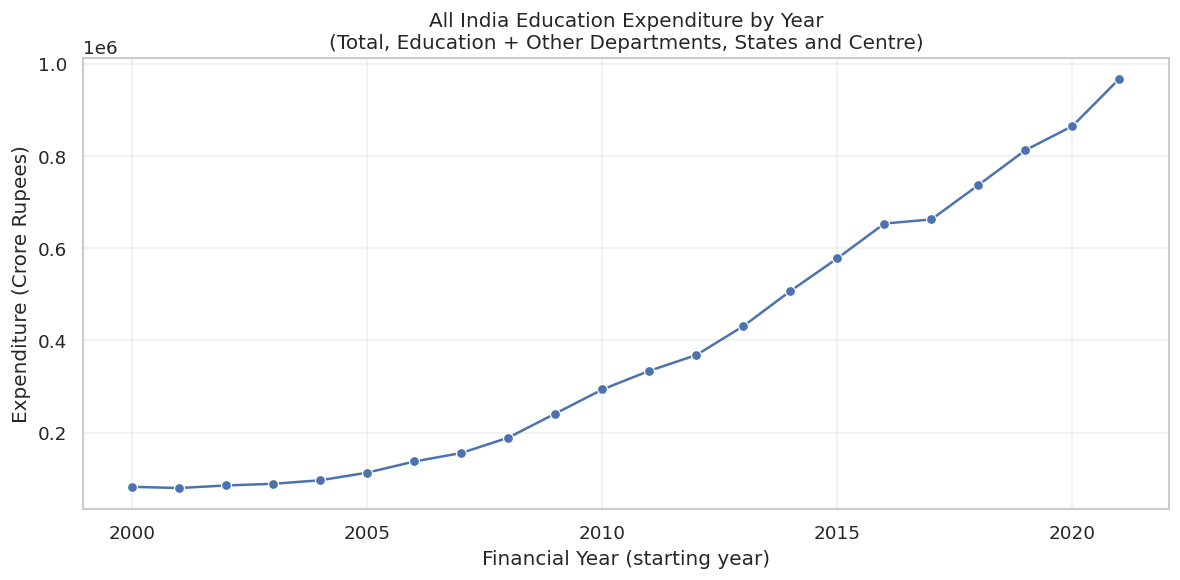

In [ ]:
# =============================================================================
# 6. SUPPORTING NATIONAL EDUCATION EXPENDITURE TRENDS (DATAFUL) – FIXED
# =============================================================================

edu_exp = edu_exp_raw.copy()
print("Education expenditure raw columns:", edu_exp.columns.tolist())

# Clean fiscal_year and create 'year' field (e.g. "2021-22" -> 2021)
edu_exp["fiscal_year"] = edu_exp["fiscal_year"].astype(str)
edu_exp["year"] = edu_exp["fiscal_year"].str.slice(0, 4).astype(int)

# Keep only entries in Crore Rupees
mask_unit = edu_exp["unit"].str.contains("Crore Rupees", case=False, na=False)

# Choose one clear series for the main trend:
# Total Expenditure on Education by Education and Other Departments, States and Centre
mask_series = (
    (edu_exp["category"] == "Total Expenditure on Education by Education and Other Departments") &
    (edu_exp["sub_category"] == "States and Centre")
)

trend_df = edu_exp[mask_unit & mask_series].copy()
print("Trend rows selected:", trend_df.shape[0])
print(trend_df[["year", "category", "sub_category", "value"]].head())

trend_df["value"] = pd.to_numeric(trend_df["value"], errors="coerce")

exp_trend = trend_df.groupby("year", as_index=False)["value"].sum()
print("Aggregated trend table:\n", exp_trend)

plt.figure(figsize=(10, 5))
sns.lineplot(data=exp_trend, x="year", y="value", marker="o")
plt.title("All India Education Expenditure by Year\n(Total, Education + Other Departments, States and Centre)")
plt.xlabel("Financial Year (starting year)")
plt.ylabel("Expenditure (Crore Rupees)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**7. Exploratory Data Analysis (EDA)**

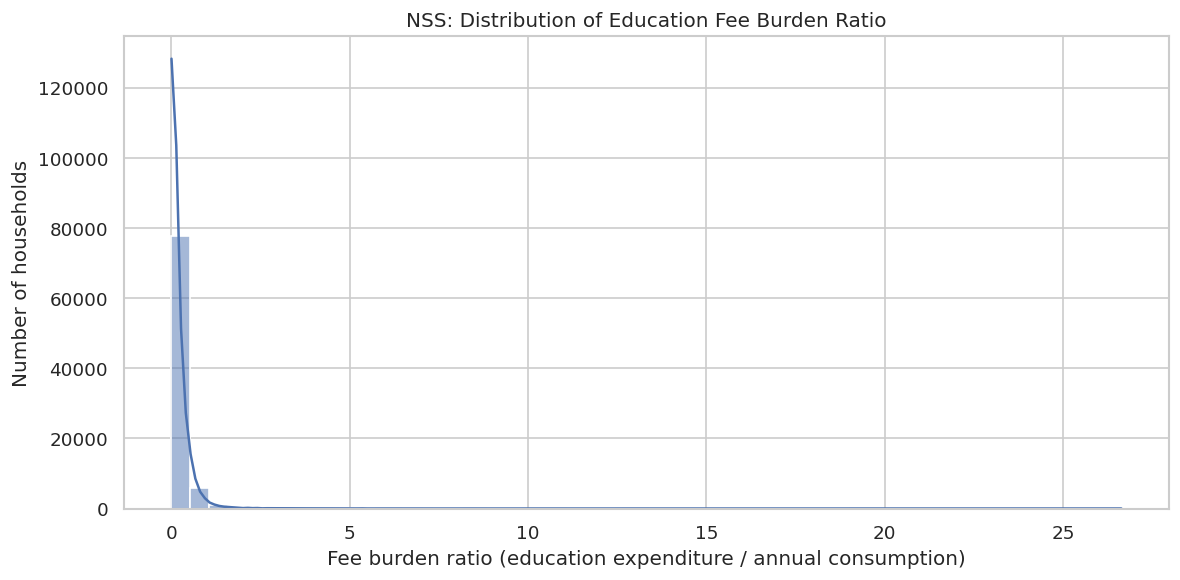

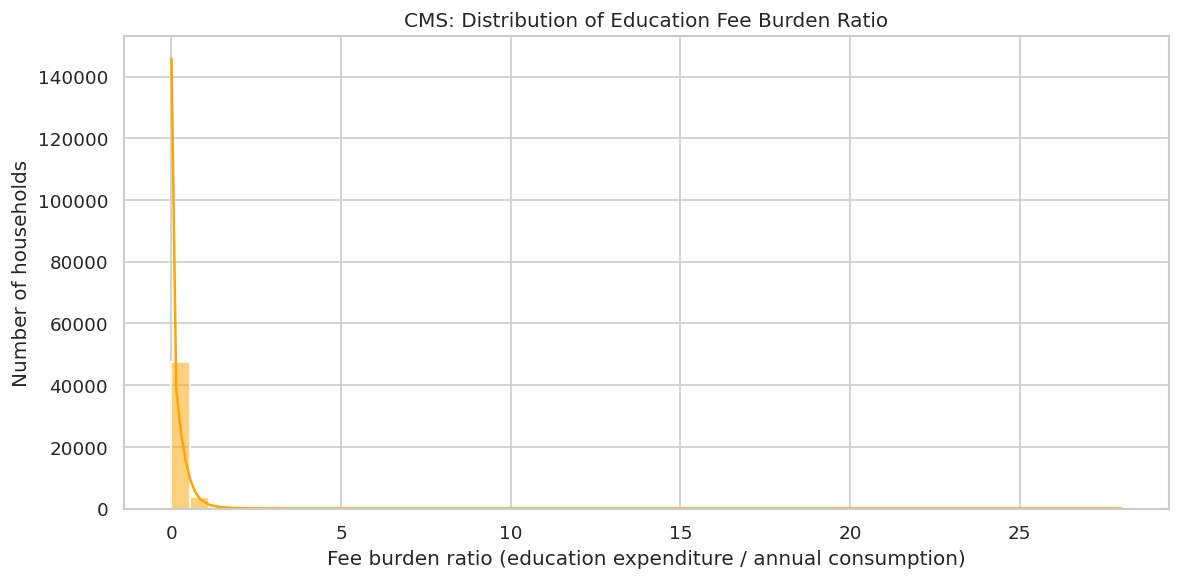

NSS high-burden share: 0.41248450644795487
CMS high-burden share: 0.44302582317365846


In [ ]:
# =============================================================================
# 7. EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

# 7.1 Fee burden ratio distributions

plt.figure(figsize=(10, 5))
sns.histplot(nss["edu_fee_burden_ratio"], bins=50, kde=True)
plt.title("NSS: Distribution of Education Fee Burden Ratio")
plt.xlabel("Fee burden ratio (education expenditure / annual consumption)")
plt.ylabel("Number of households")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(cms_hh_edu["edu_fee_burden_ratio"], bins=50, kde=True, color="orange")
plt.title("CMS: Distribution of Education Fee Burden Ratio")
plt.xlabel("Fee burden ratio (education expenditure / annual consumption)")
plt.ylabel("Number of households")
plt.tight_layout()
plt.show()

print("NSS high-burden share:", nss["high_burden"].mean())
print("CMS high-burden share:", cms_hh_edu["high_burden"].mean())

NSS high-burden rate by Sector:
    Sector  high_burden
0       1     0.341589
1       2     0.505382


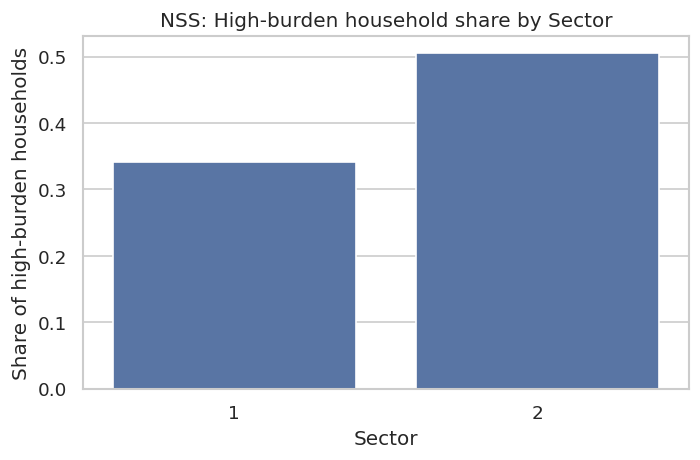

CMS high-burden rate by sector:
   sector  high_burden
0      1     0.379177
1      2     0.519591


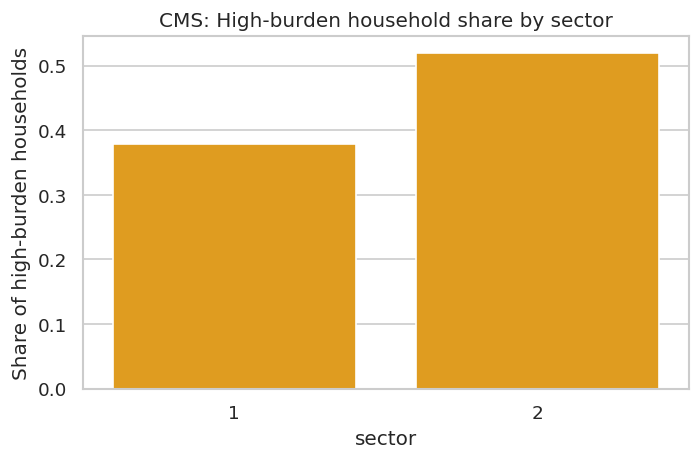

In [ ]:
# 7.2 Rural vs urban (Sector for NSS, sector for CMS)

if "Sector" in nss.columns:
    nss_sector_summary = nss.groupby("Sector")["high_burden"].mean().reset_index()
    print("NSS high-burden rate by Sector:\n", nss_sector_summary)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=nss_sector_summary, x="Sector", y="high_burden")
    plt.title("NSS: High-burden household share by Sector")
    plt.ylabel("Share of high-burden households")
    plt.tight_layout()
    plt.show()

if "sector" in cms_hh_edu.columns:
    cms_sector_summary = cms_hh_edu.groupby("sector")["high_burden"].mean().reset_index()
    print("CMS high-burden rate by sector:\n", cms_sector_summary)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=cms_sector_summary, x="sector", y="high_burden", color="orange")
    plt.title("CMS: High-burden household share by sector")
    plt.ylabel("Share of high-burden households")
    plt.tight_layout()
    plt.show()

**8. Modelling pipeline – NSS 75**

In [ ]:
# =============================================================================
# 8. MODELLING PIPELINE – NSS 75TH ROUND
# =============================================================================

# 8.1 Select features and target
nss_feature_candidates = [
    "Sector", "NSS_Region", "State", "District",
    "Stratum", "Sub_stratum",
    "Household_size", "Household_type", "HH_Type",
    "Religion", "Social_group",
    "HH_Computer", "Member_internet", "Any_HH_member_3_35yrs_attnd_edu",
    "Hostel",
    "HH_Con_exp_rs", "hh_total_edu_exp"
]
nss_feature_cols = [c for c in nss_feature_candidates if c in nss.columns]
print("NSS features used:", nss_feature_cols)

X_nss = nss[nss_feature_cols].copy()
y_nss = nss["high_burden"].copy()

nss_numeric_features = [c for c in X_nss.columns if pd.api.types.is_numeric_dtype(X_nss[c])]
nss_categorical_features = [c for c in X_nss.columns if c not in nss_numeric_features]

print("NSS numeric features:", nss_numeric_features)
print("NSS categorical features:", nss_categorical_features)

NSS features used: ['Sector', 'NSS_Region', 'State', 'District', 'Stratum', 'Sub_stratum', 'Household_size', 'Household_type', 'HH_Type', 'Religion', 'Social_group', 'HH_Computer', 'Member_internet', 'Any_HH_member_3_35yrs_attnd_edu', 'Hostel', 'HH_Con_exp_rs', 'hh_total_edu_exp']
NSS numeric features: ['Sector', 'NSS_Region', 'State', 'District', 'Stratum', 'Sub_stratum', 'Household_size', 'Household_type', 'HH_Type', 'Religion', 'Social_group', 'HH_Computer', 'Member_internet', 'Any_HH_member_3_35yrs_attnd_edu', 'Hostel', 'HH_Con_exp_rs', 'hh_total_edu_exp']
NSS categorical features: []


In [ ]:
# 8.2 Train-test split

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_nss, y_nss,
    test_size=0.2,
    random_state=42,
    stratify=y_nss
)

print("NSS train size:", Xn_train.shape, "test size:", Xn_test.shape)

NSS train size: (91005, 17) test size: (22752, 17)


In [ ]:
# 8.3 Preprocessing pipeline

nss_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

nss_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

nss_preprocess = ColumnTransformer(
    transformers=[
        ("num", nss_numeric_transformer, nss_numeric_features),
        ("cat", nss_categorical_transformer, nss_categorical_features)
    ]
)

In [ ]:
# 8.4 Define models for NSS

models_nss = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# 8.5 Train and evaluate models on NSS

nss_results = []

for name, model in models_nss.items():
    clf = Pipeline(steps=[
        ("preprocess", nss_preprocess),
        ("model", model)
    ])
    clf.fit(Xn_train, yn_train)

    y_pred = clf.predict(Xn_test)
    y_prob = clf.predict_proba(Xn_test)[:, 1]

    auc = roc_auc_score(yn_test, y_prob)
    print("\n==============================")
    print(f"NSS Model: {name}")
    print("==============================")
    print(classification_report(yn_test, y_pred, digits=3))
    print("ROC-AUC:", round(auc, 4))

    nss_results.append({"model": name, "roc_auc": auc})

nss_results_df = pd.DataFrame(nss_results).sort_values("roc_auc", ascending=False)
print("\nNSS model comparison by ROC-AUC:\n", nss_results_df)


NSS Model: LogisticRegression
              precision    recall  f1-score   support

           0      0.877     0.926     0.901     13367
           1      0.885     0.815     0.849      9385

    accuracy                          0.880     22752
   macro avg      0.881     0.870     0.875     22752
weighted avg      0.880     0.880     0.879     22752

ROC-AUC: 0.9366

NSS Model: RandomForest
              precision    recall  f1-score   support

           0      0.989     0.993     0.991     13367
           1      0.990     0.985     0.988      9385

    accuracy                          0.990     22752
   macro avg      0.990     0.989     0.989     22752
weighted avg      0.990     0.990     0.990     22752

ROC-AUC: 0.9992

NSS Model: XGBoost
              precision    recall  f1-score   support

           0      0.994     0.997     0.995     13367
           1      0.996     0.991     0.994      9385

    accuracy                          0.995     22752
   macro avg      0.

Best NSS model: RandomForest


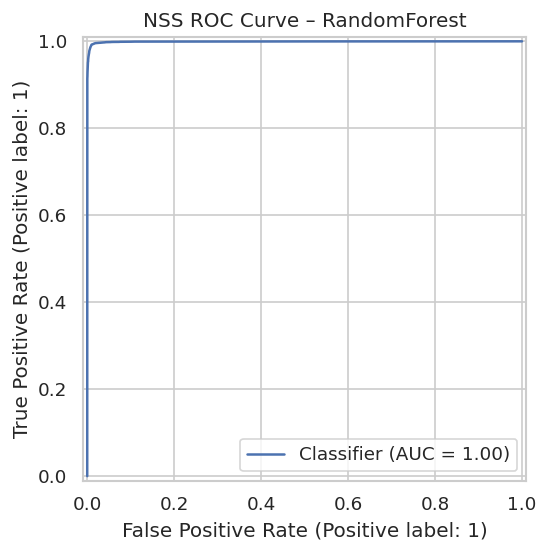

In [ ]:
# 8.6 ROC curve for best NSS model

best_nss_model_name = nss_results_df.iloc[0]["model"]
print("Best NSS model:", best_nss_model_name)

best_nss_model = Pipeline(steps=[
    ("preprocess", nss_preprocess),
    ("model", models_nss[best_nss_model_name])
])

best_nss_model.fit(Xn_train, yn_train)
y_prob_best_nss = best_nss_model.predict_proba(Xn_test)[:, 1]

RocCurveDisplay.from_predictions(yn_test, y_prob_best_nss)
plt.title(f"NSS ROC Curve – {best_nss_model_name}")
plt.show()

Computed SHAP values for NSS Random Forest sample.


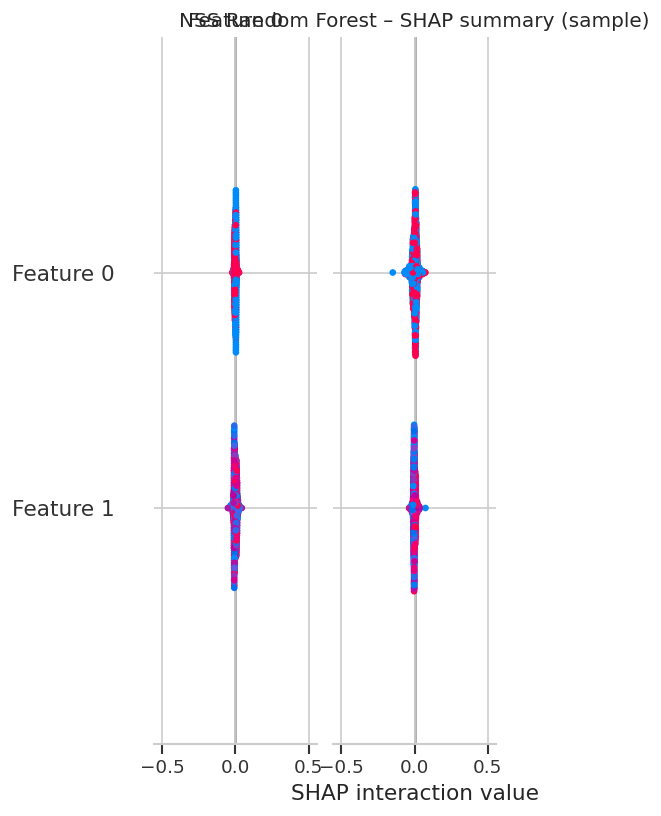

In [ ]:
# 8.7 BASIC EXPLAINABILITY FOR RANDOM FOREST ON NSS USING SHAP – FIXED

rf_nss = Pipeline(steps=[
    ("preprocess", nss_preprocess),
    ("model", models_nss["RandomForest"])
])
rf_nss.fit(Xn_train, yn_train)

# Sample from training data
sample_size = 1000
Xn_train_sample = Xn_train.sample(
    n=min(sample_size, Xn_train.shape[0]),
    random_state=42
)

# Apply preprocessing
Xn_train_proc = rf_nss.named_steps["preprocess"].transform(Xn_train_sample)

# Convert to dense float64
if sp.issparse(Xn_train_proc):
    Xn_train_proc = Xn_train_proc.toarray()
Xn_train_proc = Xn_train_proc.astype(np.float64)

rf_model_nss = rf_nss.named_steps["model"]

explainer_nss = shap.TreeExplainer(rf_model_nss)
shap_values_nss = explainer_nss.shap_values(Xn_train_proc)

print("Computed SHAP values for NSS Random Forest sample.")

# For binary classification, shap_values is a list
if isinstance(shap_values_nss, list) and len(shap_values_nss) > 1:
    shap_vals_nss_plot = shap_values_nss[1]
else:
    shap_vals_nss_plot = shap_values_nss

shap.summary_plot(shap_vals_nss_plot, Xn_train_proc, show=False)
plt.title("NSS Random Forest – SHAP summary (sample)")
plt.show()

**9. Modelling pipeline – CMS 2025**

In [ ]:
# =============================================================================
# 9. MODELLING PIPELINE – CMS 2025
# =============================================================================

# 9.1 Select features and target for CMS
cms_feature_candidates = [
    "sector", "nss_region", "district", "stratum",
    "group", "sub_stratum",
    "household_size", "household_type", "religion", "social_group",
    "any_member_attending_school", "num_members_attending_school",
    "monthly_expenditure_purchased_goods",
    "monthly_expenditure_homegrown",
    "monthly_expenditure_in_kind_gifts",
    "annual_expenditure_clothing_footwear",
    "annual_expenditure_durables",
    "usual_monthly_consumption_expenditure",
    "hh_total_edu_exp"
]

cms_feature_cols = [c for c in cms_feature_candidates if c in cms_hh_edu.columns]
print("CMS features used:", cms_feature_cols)

X_cms = cms_hh_edu[cms_feature_cols].copy()
y_cms = cms_hh_edu["high_burden"].copy()

cms_numeric_features = [c for c in X_cms.columns if pd.api.types.is_numeric_dtype(X_cms[c])]
cms_categorical_features = [c for c in X_cms.columns if c not in cms_numeric_features]

print("CMS numeric features:", cms_numeric_features)
print("CMS categorical features:", cms_categorical_features)

CMS features used: ['sector', 'nss_region', 'district', 'stratum', 'group', 'sub_stratum', 'household_size', 'household_type', 'religion', 'social_group', 'any_member_attending_school', 'num_members_attending_school', 'monthly_expenditure_purchased_goods', 'monthly_expenditure_homegrown', 'monthly_expenditure_in_kind_gifts', 'annual_expenditure_clothing_footwear', 'annual_expenditure_durables', 'usual_monthly_consumption_expenditure', 'hh_total_edu_exp']
CMS numeric features: ['household_size', 'household_type', 'religion', 'social_group', 'any_member_attending_school', 'num_members_attending_school', 'monthly_expenditure_purchased_goods', 'monthly_expenditure_homegrown', 'monthly_expenditure_in_kind_gifts', 'annual_expenditure_clothing_footwear', 'annual_expenditure_durables', 'usual_monthly_consumption_expenditure', 'hh_total_edu_exp']
CMS categorical features: ['sector', 'nss_region', 'district', 'stratum', 'group', 'sub_stratum']


In [ ]:
# 9.2 Train-test split for CMS

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cms, y_cms,
    test_size=0.2,
    random_state=42,
    stratify=y_cms
)

print("CMS train size:", Xc_train.shape, "test size:", Xc_test.shape)

CMS train size: (41668, 19) test size: (10417, 19)


In [ ]:
# 9.3 Preprocessing pipeline for CMS

cms_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cms_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

cms_preprocess = ColumnTransformer(
    transformers=[
        ("num", cms_numeric_transformer, cms_numeric_features),
        ("cat", cms_categorical_transformer, cms_categorical_features)
    ]
)

In [ ]:
# 9.4 Define models and evaluate on CMS

models_cms = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

cms_results = []

for name, model in models_cms.items():
    clf = Pipeline(steps=[
        ("preprocess", cms_preprocess),
        ("model", model)
    ])
    clf.fit(Xc_train, yc_train)

    y_pred = clf.predict(Xc_test)
    y_prob = clf.predict_proba(Xc_test)[:, 1]

    auc = roc_auc_score(yc_test, y_prob)
    print("\n==============================")
    print(f"CMS Model: {name}")
    print("==============================")
    print(classification_report(yc_test, y_pred, digits=3))
    print("ROC-AUC:", round(auc, 4))

    cms_results.append({"model": name, "roc_auc": auc})

cms_results_df = pd.DataFrame(cms_results).sort_values("roc_auc", ascending=False)
print("\nCMS model comparison by ROC-AUC:\n", cms_results_df)


CMS Model: LogisticRegression
              precision    recall  f1-score   support

           0      0.994     0.996     0.995      5802
           1      0.995     0.992     0.993      4615

    accuracy                          0.994     10417
   macro avg      0.994     0.994     0.994     10417
weighted avg      0.994     0.994     0.994     10417

ROC-AUC: 0.9999

CMS Model: RandomForest
              precision    recall  f1-score   support

           0      0.989     0.980     0.984      5802
           1      0.975     0.986     0.981      4615

    accuracy                          0.983     10417
   macro avg      0.982     0.983     0.982     10417
weighted avg      0.983     0.983     0.983     10417

ROC-AUC: 0.9986

CMS Model: XGBoost
              precision    recall  f1-score   support

           0      0.998     0.997     0.998      5802
           1      0.997     0.998     0.997      4615

    accuracy                          0.998     10417
   macro avg      0.

Best CMS model: XGBoost


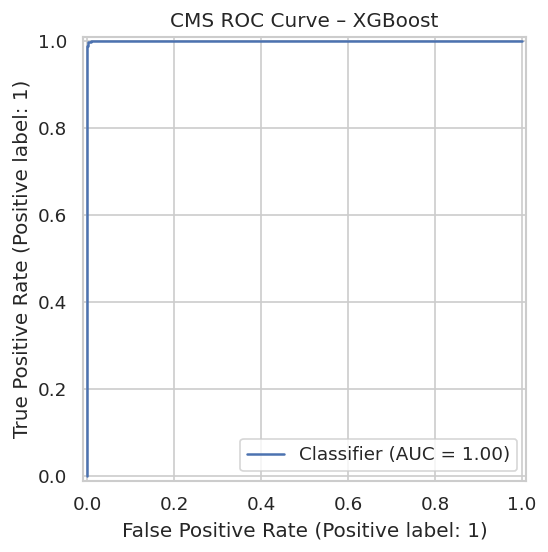

In [ ]:
# 9.5 ROC curve for best CMS model

best_cms_model_name = cms_results_df.iloc[0]["model"]
print("Best CMS model:", best_cms_model_name)

best_cms_model = Pipeline(steps=[
    ("preprocess", cms_preprocess),
    ("model", models_cms[best_cms_model_name])
])

best_cms_model.fit(Xc_train, yc_train)

y_prob_best_cms = best_cms_model.predict_proba(Xc_test)[:, 1]

RocCurveDisplay.from_predictions(yc_test, y_prob_best_cms)
plt.title(f"CMS ROC Curve – {best_cms_model_name}")
plt.show()

100%|===================| 1999/2000 [13:43<00:00]       

Computed SHAP values for CMS Random Forest sample.


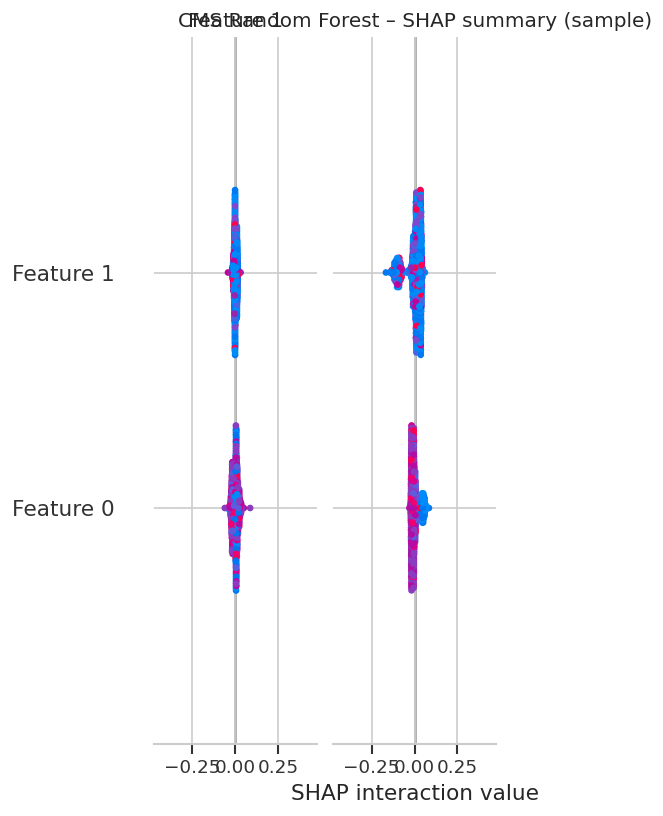

In [ ]:
# 9.6 SHAP EXPLAINABILITY FOR CMS RANDOM FOREST – FIXED

rf_cms = Pipeline(steps=[
    ("preprocess", cms_preprocess),
    ("model", models_cms["RandomForest"])
])

rf_cms.fit(Xc_train, yc_train)

sample_size = 1000
Xc_train_sample = Xc_train.sample(n=min(sample_size, Xc_train.shape[0]), random_state=42)

Xc_train_proc = rf_cms.named_steps["preprocess"].transform(Xc_train_sample)

if sp.issparse(Xc_train_proc):
    Xc_train_proc = Xc_train_proc.toarray()
Xc_train_proc = np.asarray(Xc_train_proc, dtype=np.float64)

rf_model_cms = rf_cms.named_steps["model"]

background_size = min(200, Xc_train_proc.shape[0])
background_idx = np.random.RandomState(42).choice(Xc_train_proc.shape[0], size=background_size, replace=False)
Xc_background = Xc_train_proc[background_idx]

explainer_cms = shap.TreeExplainer(
    rf_model_cms,
    data=Xc_background,
    feature_perturbation="interventional"
)

shap_values_cms = explainer_cms.shap_values(
    Xc_train_proc,
    check_additivity=False
)

print("Computed SHAP values for CMS Random Forest sample.")

if isinstance(shap_values_cms, list):
    if len(shap_values_cms) > 1:
        shap_vals_cms_plot = shap_values_cms[1]
    else:
        shap_vals_cms_plot = shap_values_cms[0]
else:
    shap_vals_cms_plot = shap_values_cms

shap.summary_plot(shap_vals_cms_plot, Xc_train_proc, show=False)
plt.title("CMS Random Forest – SHAP summary (sample)")
plt.show()

**10. Save cleaned datasets and model comparison tables**

In [ ]:
# =============================================================================
# 10. SAVE CLEANED DATA AND BASIC RESULTS
# =============================================================================

nss.to_csv(f"{BASE_PATH}/nss75_household_edu_burden_clean.csv", index=False)
cms_hh_edu.to_csv(f"{BASE_PATH}/cms2025_household_edu_burden_clean.csv", index=False)
edu_exp.to_csv(f"{BASE_PATH}/education_expenditure_clean_processed.csv", index=False)

nss_results_df.to_csv(f"{BASE_PATH}/nss_model_comparison.csv", index=False)
cms_results_df.to_csv(f"{BASE_PATH}/cms_model_comparison.csv", index=False)

print("Saved cleaned datasets and model comparison CSVs to:", BASE_PATH)

Saved cleaned datasets and model comparison CSVs to: /content/drive/My Drive/MS Drive/Masters Term 3/capstone_data
